In [1]:
from tasks.imagegen import ImageCreator
import matplotlib.pyplot as plt

In [2]:
# Initialize the ImageCreator with the input path and detector configuration. The input path can be a single FITS file, a list of FITS files, a directory containing FITS files, or a glob pattern.
creator = ImageCreator(input_path='../data/deimos_raw/d0223_0107_cti.fits', detector_config='deimos.yaml')
# Run the image creation process
df = creator.run()

Output of creator.run() is a dataframe where each row corresponds to an input file and contains a list of generated DetImage objects in the 'images' column from that input file.

In [3]:
df

,filename,image_type,processed,images
0,../data/deimos_raw/d0223_0107_cti.fits,object,True,[<datamodels.image.DetImage object at 0x1194fe...


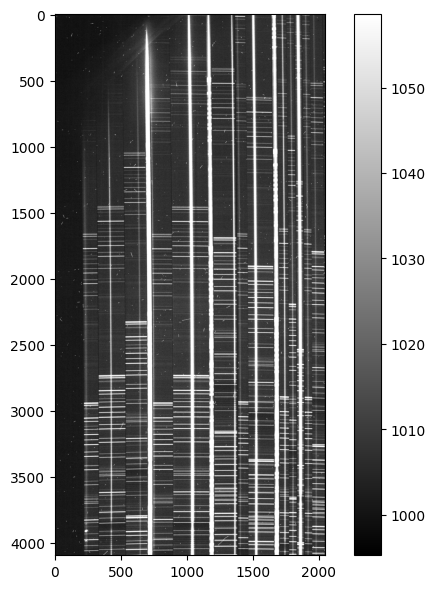

In [4]:
# Display the first DetImage from an input file
det_image = df.iloc[0]['images'][0]
# Show the DetImage using its built-in show method that takes kwargs for plt.imshow
## For example, to set the colormap to 'gray', and scale the values using vmin, vmax from ZScaleInterval:
from astropy.visualization import ZScaleInterval
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(det_image.data)
ax = det_image.show(cmap='gray', vmin=vmin, vmax=vmax)

Each DetImage object contains a list of Output objects in its 'outputs' attribute that correspond to different amplifier outputs. Each Output object is defined by data_slice, prescans, overscans, readout_pixel, etc.

In [5]:
det_image.outputs[0]

Output(id='chan_1', filename='../data/deimos_raw/d0223_0107_cti.fits', ext_id=1, ext_slice=(slice(0, 4096, None), slice(0, 1024, None)), data_slice=(slice(0, 4096, None), slice(0, 1024, None)), serial_prescan=slice(0, 0, None), serial_overscan=slice(1024, 1024, None), parallel_prescan=slice(0, 0, None), parallel_overscan=slice(4096, 4096, None), parallel_axis=0, readout_pixel=[0, 0], fits_header=None, meta={'gain': 1.0, 'read_noise': 5.0, 'bias_level': 1000}, serial_axis=1)

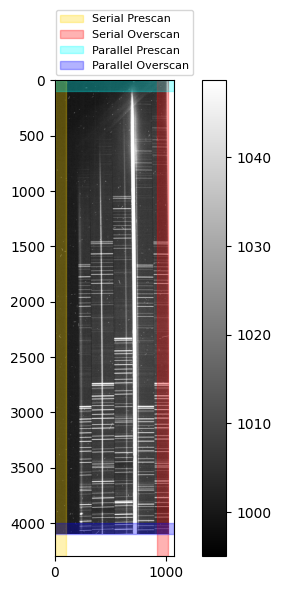

In [6]:
# Plotting the first Output
output = det_image.outputs[0]
vmin, vmax = interval.get_limits(output._data)
## Let's say the serial prescan and overscan regions are first and last 100 columns respectively
output.serial_prescan = slice(0, 100)
output.serial_overscan = slice(1024-100, 1024)
## Same for parallel prescan and overscan regions, first and last 100 rows respectively
output.parallel_prescan = slice(0, 100)
output.parallel_overscan = slice(4096-100, 4096)
ax = output.show(cmap='gray', vmin=vmin, vmax=vmax)

The DEIMOS raw FITS used above contains 8 extensions, corresponding to 8 detectors in the focal plane, each detector with two outputs.
FocalPlaneImage() class can be used to combine multiple DetImage objects into a single focal plane representation.

In [7]:
from datamodels.image import FocalPlaneImage
fpimage = FocalPlaneImage(num_detectors=8, dim=(4096*2, 2048*4), det_images=df.iloc[0]['images'])

In [8]:
fpimage.frames_df

,det_id,x_min,x_max,y_min,y_max,y_min_fp,y_max_fp,x_min_fp,x_max_fp
0,det_1,-4096.0,-2048.0,0.0,4096.0,-0.0,4096.0,0.0,2048.0
1,det_2,-2048.0,0.0,0.0,4096.0,-0.0,4096.0,2048.0,4096.0
2,det_3,0.0,2048.0,0.0,4096.0,-0.0,4096.0,4096.0,6144.0
3,det_4,2048.0,4096.0,0.0,4096.0,-0.0,4096.0,6144.0,8192.0
4,det_5,2048.0,4096.0,-4096.0,0.0,4096.0,8192.0,6144.0,8192.0
5,det_6,0.0,2048.0,-4096.0,0.0,4096.0,8192.0,4096.0,6144.0
6,det_7,-2048.0,0.0,-4096.0,0.0,4096.0,8192.0,2048.0,4096.0
7,det_8,-4096.0,-2048.0,-4096.0,0.0,4096.0,8192.0,0.0,2048.0


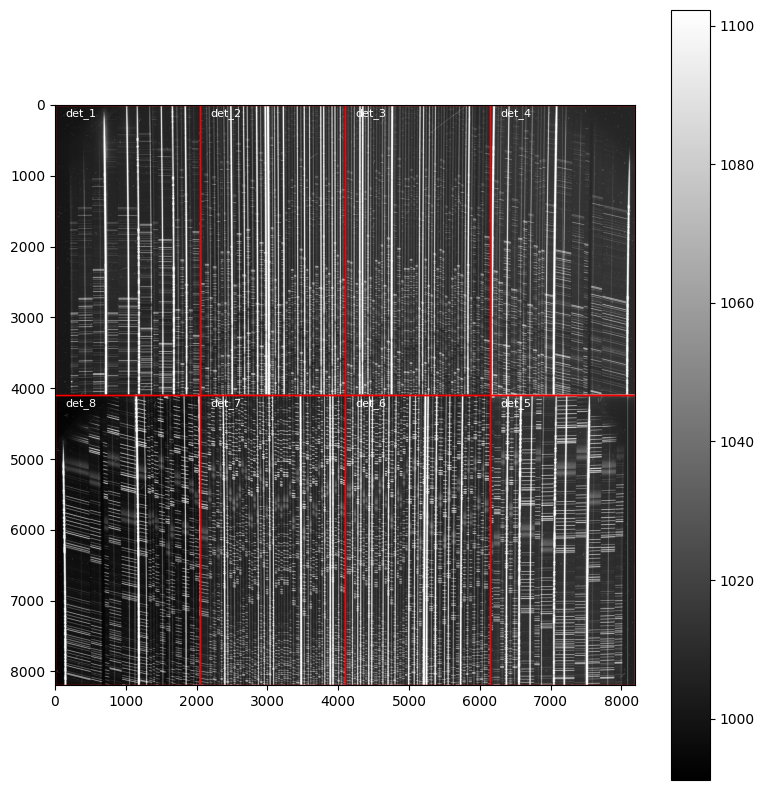

<Axes: >

In [10]:
vmin, vmax = interval.get_limits(fpimage.data)
fpimage.show(cmap='gray', vmin=vmin, vmax=vmax)